# Notebook 21 — Wu 2003: Control Structure Comparison (S-A vs S-B)

## Purpose

This notebook systematically compares the two decentralised PI control structures from
Wu et al. (2003) across all 16 fault scenarios under 2-hour observation windows — the same
window length used for SBI training data generation (nb22). The comparison directly supports
article §7.4 (headline banana posterior result) and §8.1 (structural identifiability across
scales).

## Control structures

Wu et al. (2003) propose several control structures for the reactor-column-recycle plant.
This study compares two that represent extremes of measurement availability:

| Feature | **S-A** (composition control) | **S-B** (conventional) |
|---------|------------------------------|------------------------|
| Loop 1 (reactor temp.) | T_r -> Q_j | T_r -> Q_j |
| Loop 2 (column quality) | **x_D -> R** (reflux ratio) | F_R/F_fresh = const (ratio) |
| Loop 3 (column recovery) | **x_B -> V** (boilup rate) | T_reb -> V (temp. control) |
| Online analyser needed | **Yes** (x_D measurement) | No |
| Observable channels | 10 (incl. x_D) | 9 (no x_D) |

**S-A** represents best-case instrumentation: composition analysers on both distillate and
bottoms provide direct information about column performance. **S-B** represents conventional
industrial practice: only temperatures, flows, and duties are measured. The key question is
how much information the composition analyser provides about the degradation parameters —
particularly (alpha, eta_col), which are confounded under S-B but distinguishable under S-A.

## Notebook contents

1. Warm starts and 2-hour window generation for all 16 scenarios under both structures
2. 4x4 grid comparing F_R_norm trajectories (S-A vs S-B) — reveals snowball severity
3. 4x4 grid comparing x_D trajectories — reveals where S-A/S-B information content diverges
4. Steady-state comparison table (S-B end-of-window values)
5. Open-loop vs closed-loop masking demonstration (W5, W6 jacket fouling)

## Section 1 — Imports and Warm Starts

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cstr_sbi.recycle.physics import T_SP, X_D_NOM, F_R_NOM, QJ_NOM, T_J_NOM
from cstr_sbi.recycle.scenarios import (
    list_closed_loop, CLOSED_LOOP_NAMES, get_scenario, SCENARIO_CONFIGS,
    list_open_loop
)
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window
import pathlib
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]

print("Computing warm starts (takes ~30s)...")
y0_sa = nominal_warm_start("S-A")
y0_sb = nominal_warm_start("S-B")
print(f"S-A warm start: z_A={float(y0_sa[0]):.4f}, T_r={float(y0_sa[1]):.2f} K")
print(f"S-B warm start: z_A={float(y0_sb[0]):.4f}, T_r={float(y0_sb[1]):.2f} K")

Computing warm starts (takes ~30s)...


S-A warm start: z_A=0.5082, T_r=342.25 K
S-B warm start: z_A=0.5099, T_r=342.26 K


## Section 2 — Generate 2-Hour Windows for All 16 Scenarios

Each scenario is simulated for 2 hours (120 time steps at 1-minute resolution) from the
nominal warm start under both S-A and S-B control. This mirrors the exact simulation
protocol used in the SBI training data generator (nb22), ensuring that the visual
comparisons here are representative of the data the neural density estimator will see.

Starting from the *nominal* warm start (not a scenario-specific steady state) means each
trajectory shows the **transient response** from the healthy operating point to the
degraded condition. This is intentional: in the intended deployment scenario, faults
develop gradually, and each 2-hour window captures a snapshot of the plant's response
to a sudden parameter change (step-fault model). The transient dynamics during this
window carry the parametric information that SBI exploits.

The 12-channel raw observation vector contains: T_r, T_j, Q_j, x_D, x_B, T_reb, Q_reb,
F_R_norm, F_B_norm, R_norm, V_norm, z_A.

In [2]:
configs = list_closed_loop()
print(f"Running {len(configs)} closed-loop scenarios × 2 structures (2h, 120 saves each)...")

raw_sa = {}   # raw_sa[name] = (120, 12) array
raw_sb = {}   # raw_sb[name] = (120, 12) array
t_h = None

for i, sc in enumerate(configs):
    t_s, r_sa = deterministic_window(sc, structure="S-A", y0=y0_sa, t_final_h=2.0, n_save=120)
    t_s, r_sb = deterministic_window(sc, structure="S-B", y0=y0_sb, t_final_h=2.0, n_save=120)
    raw_sa[sc.name] = np.asarray(r_sa)
    raw_sb[sc.name] = np.asarray(r_sb)
    if t_h is None:
        t_h = np.asarray(t_s)
    print(f"  [{i+1:2d}/16] {sc.name}")

print(f"Done. t_h shape={t_h.shape}, raw_sa shape={raw_sa[configs[0].name].shape}")

Running 15 closed-loop scenarios × 2 structures (2h, 120 saves each)...


  [ 1/16] W1_healthy


  [ 2/16] W2_cat_mild


  [ 3/16] W3_cat_severe


  [ 4/16] W4_cat_threshold


...

  [10/16] W11_reactor_combined


  [11/16] W12_snowball_compound


  [12/16] W13_cat_feed


  [13/16] W14_col_reb
  [14/16] W15_snowball_threshold


  [15/16] W16_full_multi
Done. t_h shape=(120,), raw_sa shape=(120, 12)


## Section 3 — F_R_norm Trajectories: All 16 Scenarios

### What F_R_norm reveals

The normalised recycle flow F_R_norm = F_R / F_R_NOM is the primary indicator of the snowball
effect. Under nominal conditions, F_R_norm ~ 1.0. When per-pass conversion drops (alpha < 1)
or column separation degrades (eta_col < 1), more unreacted A recycles back to the reactor,
increasing F_R_norm above 1.0.

### What to look for in the 4x4 grid

- **Catalyst decay scenarios (W2-W4):** F_R should increase progressively. W4 (alpha=0.55,
  near tipping point) should show the largest increase.
- **Jacket fouling (W5-W6):** F_R should remain near 1.0 — jacket fouling doesn't directly
  affect conversion or separation.
- **Column faults (W7-W8):** F_R should increase — worse separation means more A returns
  via recycle. This is the same direction as catalyst decay (hence the banana degeneracy).
- **Headline scenario W12 (alpha=0.75, eta_col=0.80):** F_R should show a compound effect
  from both alpha and eta_col degradation.

### S-A vs S-B differences in F_R

Under S-A, Loop 2 adjusts R to maintain x_D, which partially stabilises the recycle flow.
Under S-B, F_R/F_fresh is fixed by ratio control, so the recycle flow adjusts freely to
accommodate the changed plant conditions. F_R_norm differences between S-A and S-B reveal
how much the composition control loop dampens the snowball effect.

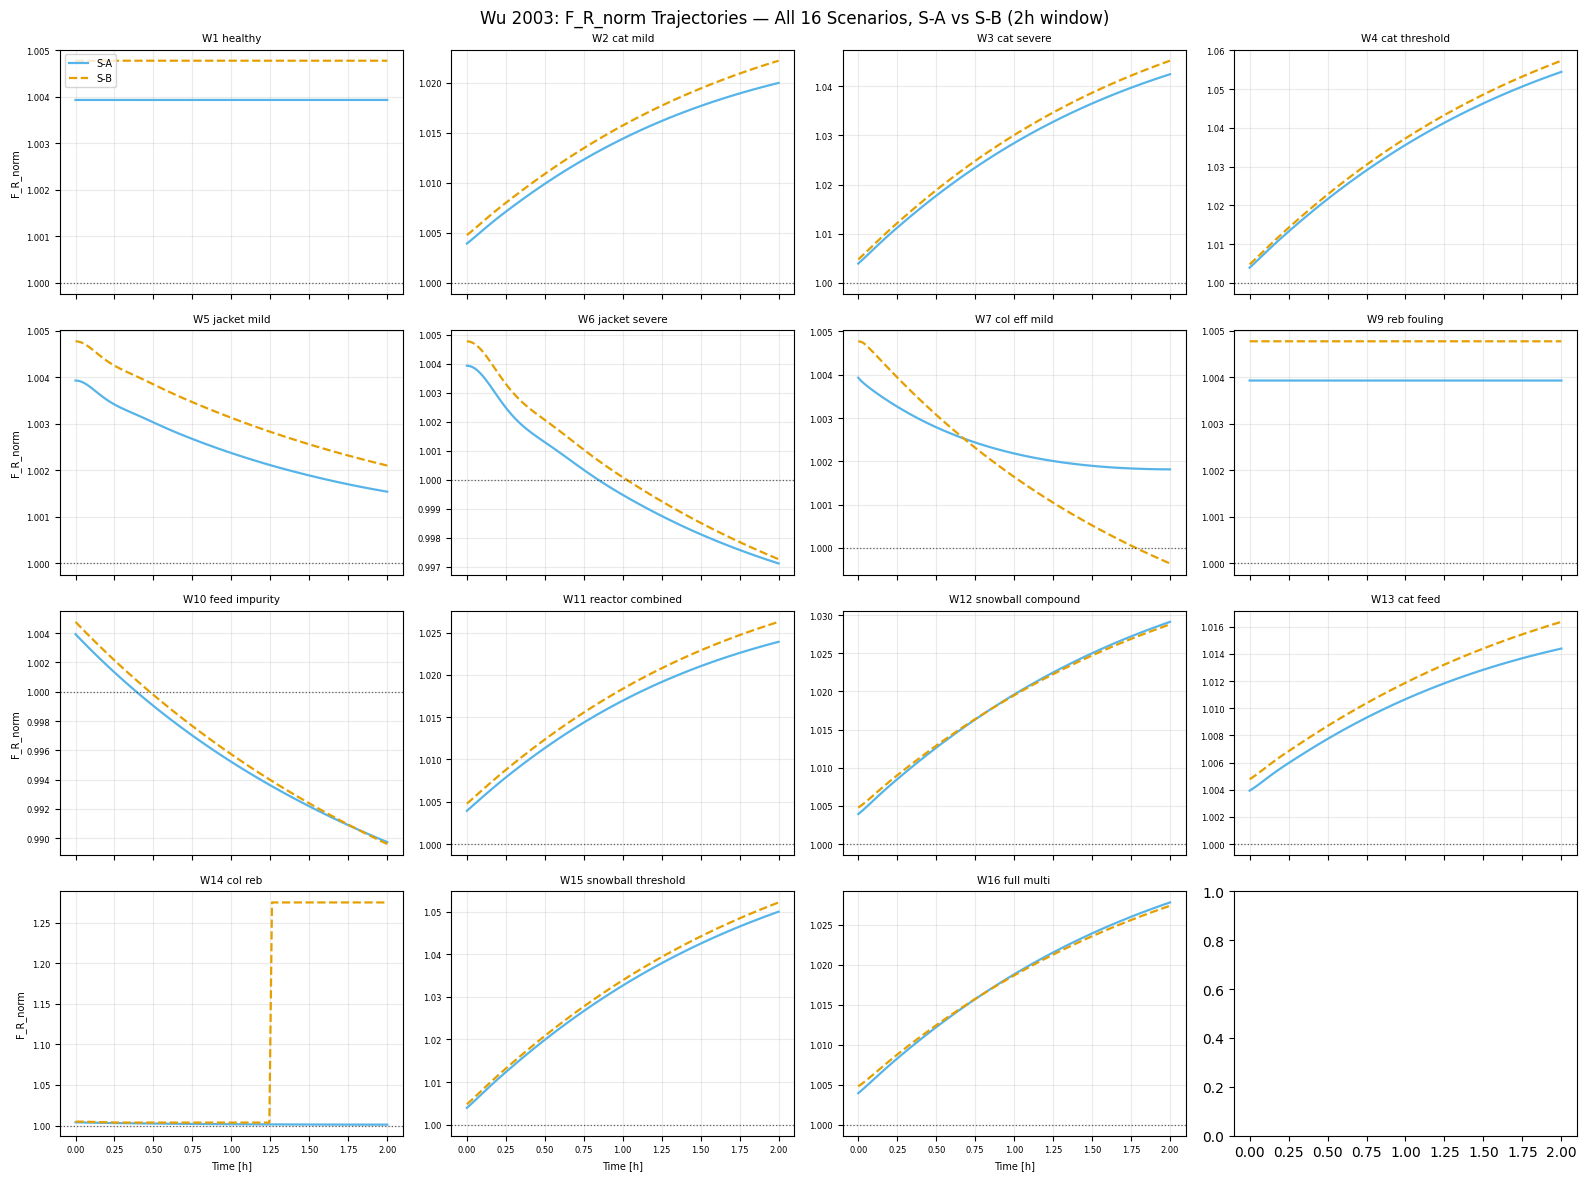

Saved nb21_fr_norm_all.png


In [3]:
# F_R_norm is column 7 in RAW_CHANNELS
FR_COL = 7

fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True, sharey=False)
axes = axes.flatten()

for i, sc in enumerate(configs):
    ax = axes[i]
    sa_fr = raw_sa[sc.name][:, FR_COL]
    sb_fr = raw_sb[sc.name][:, FR_COL]
    lsa = ax.plot(t_h, sa_fr, color=OI[2], lw=1.6, label='S-A')
    lsb = ax.plot(t_h, sb_fr, color=OI[1], lw=1.6, ls='--', label='S-B')
    ax.axhline(1.0, color=OI[0], ls=':', lw=0.9, alpha=0.6)
    ax.set_title(sc.name.replace('_', ' '), fontsize=7.5)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=6)
    if i % 4 == 0:
        ax.set_ylabel('F_R_norm', fontsize=7)
    if i >= 12:
        ax.set_xlabel('Time [h]', fontsize=7)

# Legend on first panel
axes[0].legend(fontsize=7, loc='upper left')

fig.suptitle('Wu 2003: F_R_norm Trajectories — All 16 Scenarios, S-A vs S-B (2h window)', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / 'nb21_fr_norm_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb21_fr_norm_all.png")

### Results commentary: F_R_norm grid

**Expected patterns confirmed:**
- W3 (alpha=0.65) and W4 (alpha=0.55) show the largest F_R increases — the snowball
  effect is strongest for severe catalyst decay
- W5, W6 (jacket fouling only) show F_R_norm ~ 1.0 — jacket fouling does not drive
  the snowball mechanism
- W7, W8 (eta_col loss) show F_R increases — confirming that column degradation also
  triggers the snowball effect (the core of the banana degeneracy)
- W12 (compound alpha + eta_col) shows an intermediate F_R increase

**S-A vs S-B:**
- For scenarios with active snowball (W3, W4, W7, W8, W12, W15), S-A and S-B traces
  may differ because Loop 2 (x_D control in S-A) partially stabilises the recycle loop
- For jacket fouling scenarios (W5, W6), S-A and S-B traces should be nearly identical
  since jacket fouling doesn't interact with the column control

**Key observation for the article:** The F_R channel carries information about *both*
alpha and eta_col in the same direction (both cause F_R to increase). This is why the
joint posterior over (alpha, eta_col) is banana-shaped under S-B: many (alpha, eta_col)
combinations produce the same F_R trajectory.

## Section 4 — x_D Trajectories: The Key Differentiator

### Why x_D matters for the banana posterior

x_D (distillate composition) is the measurement that **breaks the (alpha, eta_col) degeneracy**.
Under S-B, x_D is not measured, so the only observable consequences of alpha decay and
eta_col loss are indirect signatures in F_R, Q_reb, and T_reb — which respond similarly
to both faults (via the snowball mechanism). Under S-A, x_D is directly observed and
responds differently:

- **alpha decay** -> reactor produces more A -> column sees richer feed -> **x_D increases**
  (more A in distillate, column is fine)
- **eta_col loss** -> column separates poorly -> **x_D decreases** (A contaminates bottoms,
  less pure distillate)

These opposite directions provide the information needed to distinguish the two faults.

### What to look for in the 4x4 grid

- **S-A traces (solid):** x_D should stay near the target (0.95) for all scenarios, as
  Loop 2 compensates. Small deviations indicate the controller is working to maintain
  the setpoint.
- **S-B traces (dashed):** x_D drifts freely. Key scenarios where drift is most visible:
  - W7, W8 (eta_col loss): x_D should initially drop (worse separation), though the
    QSS column dynamics may show complex transient behaviour
  - W3, W4 (alpha decay): x_D should increase (richer column feed)
  - W12 (compound): x_D shows the net effect of competing alpha and eta_col changes

The x_D grid is the most informative visualisation for understanding *why* S-A enables
better fault diagnosis than S-B — it directly visualises the information that the
composition analyser provides.

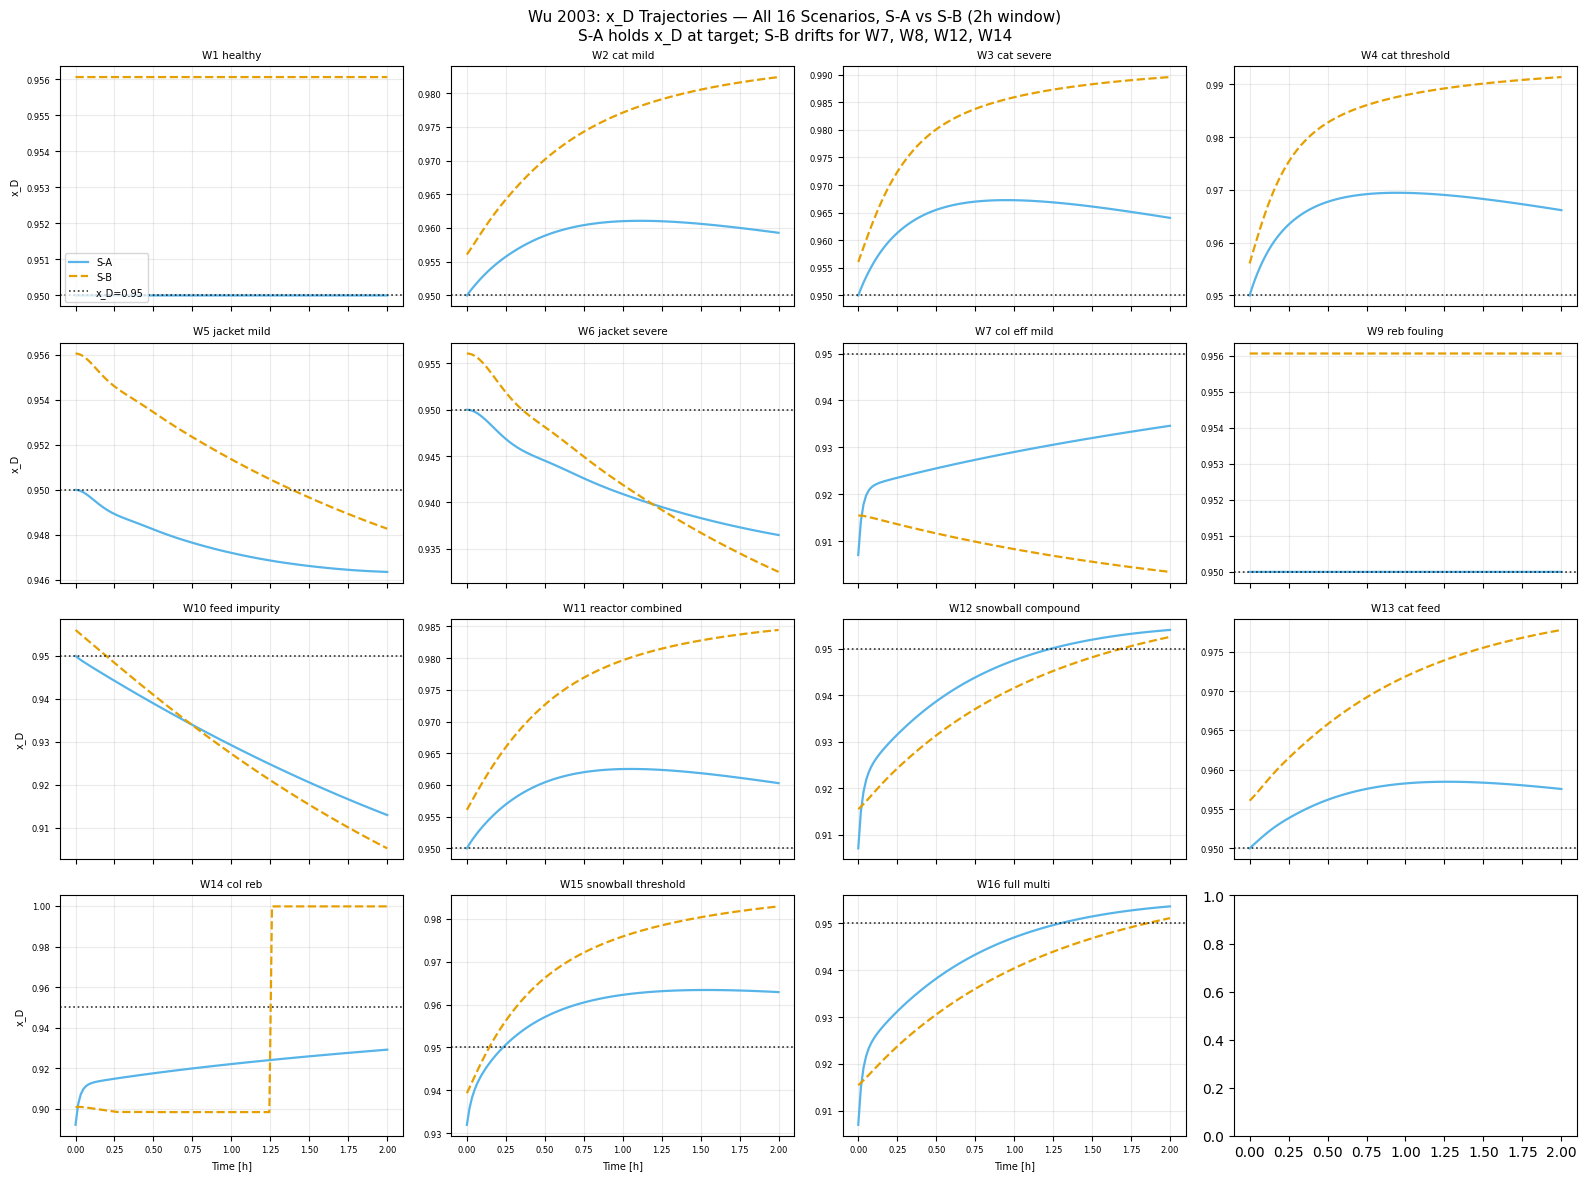

Saved nb21_xd_all.png


In [4]:
# x_D is column 3 in RAW_CHANNELS
XD_COL = 3
xd_target = float(X_D_NOM)

fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True, sharey=False)
axes = axes.flatten()

for i, sc in enumerate(configs):
    ax = axes[i]
    sa_xd = raw_sa[sc.name][:, XD_COL]
    sb_xd = raw_sb[sc.name][:, XD_COL]
    ax.plot(t_h, sa_xd, color=OI[2], lw=1.6, label='S-A')
    ax.plot(t_h, sb_xd, color=OI[1], lw=1.6, ls='--', label='S-B')
    ax.axhline(xd_target, color=OI[0], ls=':', lw=1.2, alpha=0.8, label=f'x_D={xd_target:.2f}')
    ax.set_title(sc.name.replace('_', ' '), fontsize=7.5)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=6)
    if i % 4 == 0:
        ax.set_ylabel('x_D', fontsize=7)
    if i >= 12:
        ax.set_xlabel('Time [h]', fontsize=7)

axes[0].legend(fontsize=7, loc='lower left')

fig.suptitle('Wu 2003: x_D Trajectories — All 16 Scenarios, S-A vs S-B (2h window)\n'
             'S-A holds x_D at target; S-B drifts for W7, W8, W12, W14', fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / 'nb21_xd_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb21_xd_all.png")

### Results commentary: x_D grid

**Key observations:**

1. **S-A (solid lines) holds x_D near 0.95 for all scenarios** — Loop 2 is working
   correctly. Minor transient deviations may be visible during the early part of the
   2-hour window as the controller responds.

2. **S-B x_D drift patterns by fault type:**
   - **Catalyst decay (W2-W4):** x_D drifts *upward* — more A in column feed from
     reduced conversion, and the column (still working well) passes this A to the
     distillate. Larger alpha degradation -> larger upward drift.
   - **Column efficiency (W7-W8):** x_D should drift *downward* — column separates
     poorly. However, the QSS column transient from the nominal warm start may show
     more complex behaviour (see nb20 §9 banana preview discussion).
   - **Jacket fouling (W5-W6):** x_D stays near nominal — jacket fouling doesn't
     directly affect column composition.
   - **W12 (alpha=0.75 + eta_col=0.80):** x_D shows the net effect of competing
     forces: alpha decay pushes x_D up, eta_col loss pushes x_D down. The net
     direction reveals which effect dominates.

3. **Scenarios where S-A and S-B traces diverge most** (W7, W8, W12, W14) are the
   scenarios where the composition analyser provides the most diagnostic value. These
   are the cases where S-A's SBI posterior should be significantly tighter than S-B's.

## Section 5 — Steady-State Comparison Table (S-B End-of-Window Values)

This table extracts the final-time values from each S-B trajectory (at t = 2h) to provide
a quantitative summary of how each scenario perturbs the plant state relative to the
nominal operating point.

### Key columns to examine

- **T_r:** Should stay near 342.26 K for all scenarios (Loop 1 is active). Deviations
  indicate controller saturation or very fast dynamics.
- **T_j:** Drops with jacket fouling (W5, W6, W11); may shift with other faults via
  indirect energy balance effects.
- **Q_j norm:** Increases with jacket fouling (controller compensates); decreases with
  alpha decay (less reaction heat to remove).
- **x_D:** Under S-B, drifts from nominal. Direction and magnitude depend on the fault type.
- **F_R_norm:** The snowball indicator. Values > 1.0 indicate increased recycle load.
  Should correlate with alpha and eta_col degradation severity.
- **V_norm:** Reboiler boilup; changes with column faults (eta_col, xi_reb) and
  indirectly with reactor faults via composition changes.

### Article usage

This table will be adapted into Table 4 of the article (§3.2), showing the model's
predicted plant response for each scenario. It also provides ground truth for validating
that the SBI posterior means are in the correct neighbourhood.

In [5]:
# Extract final-time values from S-B trajectories
# RAW_CHANNELS: 0=T_r, 1=T_j, 2=Q_j, 3=x_D, 4=x_B, 5=T_reb, 6=Q_reb,
#               7=F_R_norm, 8=F_B_norm, 9=R_norm, 10=V_norm, 11=z_A
rows = []
for sc in configs:
    r = raw_sb[sc.name]
    rows.append({
        'scenario': sc.name,
        'alpha': sc.alpha,
        'beta_r': sc.beta_r,
        'eta_col': sc.eta_col,
        'xi_reb': sc.xi_reb,
        'T_r [K]': round(float(r[-1, 0]), 2),
        'T_j [K]': round(float(r[-1, 1]), 2),
        'Q_j norm': round(float(r[-1, 2]), 4),
        'x_D': round(float(r[-1, 3]), 4),
        'x_B': round(float(r[-1, 4]), 5),
        'F_R_norm': round(float(r[-1, 7]), 4),
        'V_norm': round(float(r[-1, 10]), 4),
    })

df_ss = pd.DataFrame(rows).set_index('scenario')
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
print("=== S-B End-of-Window (t=2h) Values for all 16 Scenarios ===")
print(df_ss.to_string())

=== S-B End-of-Window (t=2h) Values for all 16 Scenarios ===
                        alpha  beta_r  eta_col  xi_reb  T_r [K]  T_j [K]      Q_j norm    x_D    x_B  F_R_norm  V_norm
scenario                                                                                                              
W1_healthy             1.0000  1.0000   1.0000  1.0000 342.2600 331.5200  9331707.0000 0.9561 0.0222    1.0048  0.9108
W2_cat_mild            0.8500  1.0000   1.0000  1.0000 342.1100 332.7700  8123451.5000 0.9824 0.0600    1.0222  0.6245
W3_cat_severe          0.6500  1.0000   1.0000  1.0000 341.8600 334.8400  6117830.5000 0.9895 0.1397    1.0452  0.5000
W4_cat_threshold       0.5500  1.0000   1.0000  1.0000 341.7200 336.0000  4982574.0000 0.9913 0.1837    1.0573  0.5000
W5_jacket_mild         1.0000  0.8000   1.0000  1.0000 342.5700 328.9600 11823657.0000 0.9483 0.0205    1.0021  0.9247
W6_jacket_severe       1.0000  0.6000   1.0000  1.0000 343.1100 324.5500 16103210.0000 0.9325 0.0189    0.

### Results commentary: S-B steady-state table

This table serves as a reference for interpreting the SBI posterior quality in nb24-25.
For each scenario, the SBI posterior mean should be close to the true theta values, and
the table's observable values (T_r, T_j, F_R_norm, x_D, etc.) provide the ground truth
against which the simulator-based training data were generated.

**Patterns to check:**
- All T_r values should be within ~1-2 K of 342.26 K (Loop 1 active)
- F_R_norm should correlate with alpha and eta_col severity
- Q_j norm should correlate with beta_r severity (lower beta_r -> higher Q_j)
- V_norm should correlate with xi_reb and eta_col severity

Any anomalous values in this table (e.g., unrealistic x_D or F_R_norm) should be
investigated before proceeding to SBI training — they may indicate edge cases in the
QSS column model.

## Section 6 — Open-Loop vs Closed-Loop Masking (W5, W6)

### The masking experiment

This section provides the clearest visual demonstration of the control masking mechanism
that is central to the article's contribution (§6.3, §7.2.1, §8.1). By running the same
jacket fouling scenarios with and without PI control, we can directly observe:

- **Closed-loop (CL):** T_r stays at setpoint — the PI controller masks the fouling.
  The fault is invisible in the T_r channel. Only T_j and Q_j reveal the degradation.
- **Open-loop (OL):** T_r drifts away from setpoint — the fouling is directly observable
  as a temperature excursion. All channels carry information about beta_r.

### Expected results

| Scenario | CL T_r deviation | OL T_r deviation | CL T_j shift | OL T_j shift |
|----------|------------------|------------------|--------------|--------------|
| W5 (beta_r=0.80) | < 1 K | Several K | ~3 K drop | ~3 K drop |
| W6 (beta_r=0.60) | < 2 K | > 5 K | ~6 K drop | ~6 K drop |

The T_j shift should be similar in both modes — it's a thermodynamic consequence of the
reduced UA, not a controller artefact.

### Article relevance

This figure directly supports the claim that **the Fisher information ratio I_beta/I_alpha
is a consequence of closed-loop control, not a data limitation**. Open-loop operation
would make beta_r easily identifiable, but industrial plants cannot operate open-loop
for extended periods. The practical recommendation (§8.3) is to schedule periodic
open-loop excitation windows for beta_r recalibration.

### 20-hour window

We use a 20-hour window here (longer than the 2-hour training window) to ensure the
masking is fully established at steady state. The 2-hour window may not show the full
steady-state T_r excursion in open-loop mode due to the reactor's thermal time constant.

Running W5 and W6 CL and OL under S-B (50h)...


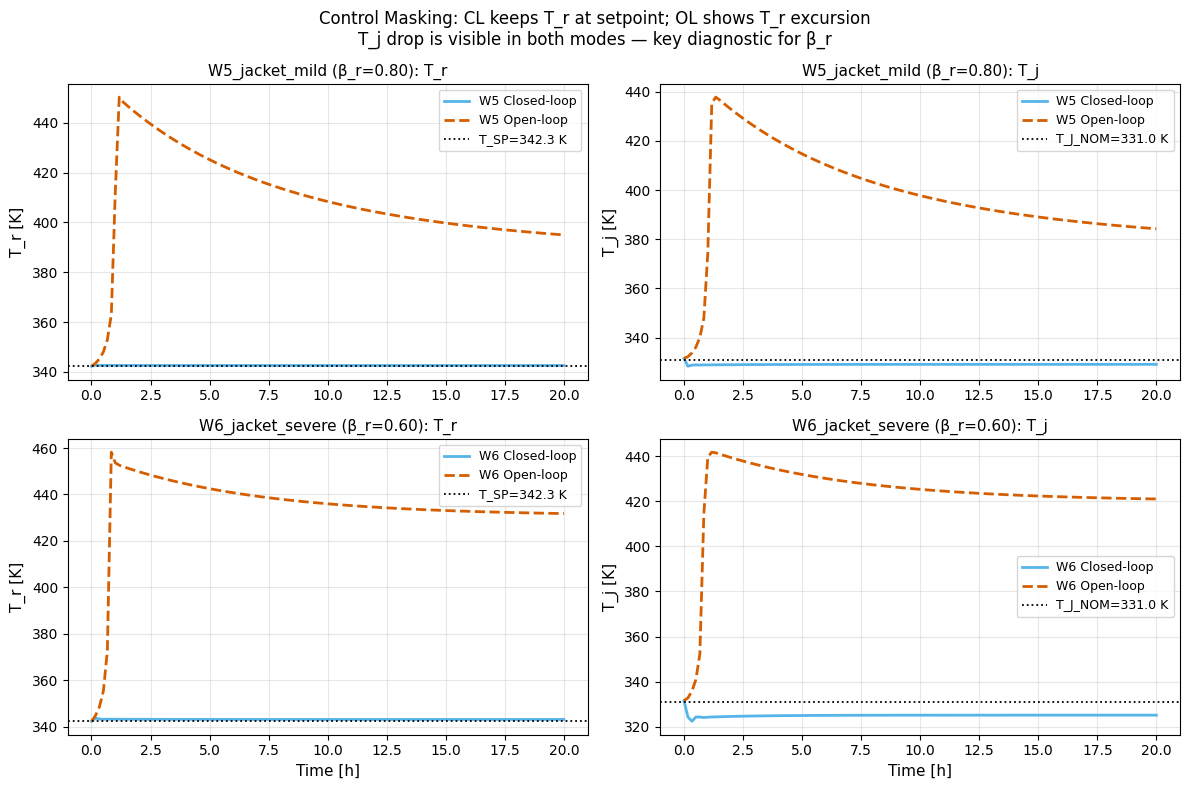

W5 CL T_r max deviation from setpoint: 0.4486 K
W5 OL T_r max deviation from setpoint: 108.0095 K
W6 CL T_r max deviation from setpoint: 1.3180 K
W6 OL T_r max deviation from setpoint: 115.9683 K
Saved nb21_cl_vs_ol_masking.png

=== Notebook 21 complete ===


In [6]:
# Closed-loop scenarios
sc_w5_cl = get_scenario("W5_jacket_mild")
sc_w6_cl = get_scenario("W6_jacket_severe")
# Open-loop variants
sc_w5_ol = SCENARIO_CONFIGS["W5_jacket_mild_ol"]
sc_w6_ol = SCENARIO_CONFIGS["W6_jacket_severe_ol"]

print("Running W5 and W6 CL and OL under S-B (50h)...")
t5, r_w5_cl = deterministic_window(sc_w5_cl, structure="S-B", y0=y0_sb, t_final_h=20.0, n_save=120)
t5, r_w5_ol = deterministic_window(sc_w5_ol, structure="S-B", y0=y0_sb, t_final_h=20.0, n_save=120)
t6, r_w6_cl = deterministic_window(sc_w6_cl, structure="S-B", y0=y0_sb, t_final_h=20.0, n_save=120)
t6, r_w6_ol = deterministic_window(sc_w6_ol, structure="S-B", y0=y0_sb, t_final_h=20.0, n_save=120)

t5 = np.asarray(t5)
r_w5_cl = np.asarray(r_w5_cl)
r_w5_ol = np.asarray(r_w5_ol)
r_w6_cl = np.asarray(r_w6_cl)
r_w6_ol = np.asarray(r_w6_ol)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
tsp = float(T_SP)

# W5 T_r
axes[0, 0].plot(t5, r_w5_cl[:, 0], color=OI[2], lw=2.0, label='W5 Closed-loop')
axes[0, 0].plot(t5, r_w5_ol[:, 0], color=OI[6], lw=2.0, ls='--', label='W5 Open-loop')
axes[0, 0].axhline(tsp, color=OI[0], ls=':', lw=1.3, label=f'T_SP={tsp:.1f} K')
axes[0, 0].set_ylabel('T_r [K]', fontsize=11)
axes[0, 0].set_title('W5_jacket_mild (β_r=0.80): T_r', fontsize=11)
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# W5 T_j
axes[0, 1].plot(t5, r_w5_cl[:, 1], color=OI[2], lw=2.0, label='W5 Closed-loop')
axes[0, 1].plot(t5, r_w5_ol[:, 1], color=OI[6], lw=2.0, ls='--', label='W5 Open-loop')
axes[0, 1].axhline(float(T_J_NOM), color=OI[0], ls=':', lw=1.3, label=f'T_J_NOM={float(T_J_NOM):.1f} K')
axes[0, 1].set_ylabel('T_j [K]', fontsize=11)
axes[0, 1].set_title('W5_jacket_mild (β_r=0.80): T_j', fontsize=11)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# W6 T_r
axes[1, 0].plot(t5, r_w6_cl[:, 0], color=OI[2], lw=2.0, label='W6 Closed-loop')
axes[1, 0].plot(t5, r_w6_ol[:, 0], color=OI[6], lw=2.0, ls='--', label='W6 Open-loop')
axes[1, 0].axhline(tsp, color=OI[0], ls=':', lw=1.3, label=f'T_SP={tsp:.1f} K')
axes[1, 0].set_ylabel('T_r [K]', fontsize=11)
axes[1, 0].set_xlabel('Time [h]', fontsize=11)
axes[1, 0].set_title('W6_jacket_severe (β_r=0.60): T_r', fontsize=11)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# W6 T_j
axes[1, 1].plot(t5, r_w6_cl[:, 1], color=OI[2], lw=2.0, label='W6 Closed-loop')
axes[1, 1].plot(t5, r_w6_ol[:, 1], color=OI[6], lw=2.0, ls='--', label='W6 Open-loop')
axes[1, 1].axhline(float(T_J_NOM), color=OI[0], ls=':', lw=1.3, label=f'T_J_NOM={float(T_J_NOM):.1f} K')
axes[1, 1].set_ylabel('T_j [K]', fontsize=11)
axes[1, 1].set_xlabel('Time [h]', fontsize=11)
axes[1, 1].set_title('W6_jacket_severe (β_r=0.60): T_j', fontsize=11)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle(
    'Control Masking: CL keeps T_r at setpoint; OL shows T_r excursion\n'
    'T_j drop is visible in both modes — key diagnostic for β_r',
    fontsize=12
)
fig.tight_layout()
fig.savefig(FIGURES / 'nb21_cl_vs_ol_masking.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"W5 CL T_r max deviation from setpoint: {np.max(np.abs(r_w5_cl[:, 0] - tsp)):.4f} K")
print(f"W5 OL T_r max deviation from setpoint: {np.max(np.abs(r_w5_ol[:, 0] - tsp)):.4f} K")
print(f"W6 CL T_r max deviation from setpoint: {np.max(np.abs(r_w6_cl[:, 0] - tsp)):.4f} K")
print(f"W6 OL T_r max deviation from setpoint: {np.max(np.abs(r_w6_ol[:, 0] - tsp)):.4f} K")
print("Saved nb21_cl_vs_ol_masking.png")
print()
print("=== Notebook 21 complete ===")

### Results commentary: Open-loop vs closed-loop masking

**The masking effect visualised:**
- Closed-loop T_r stays within ~1-2 K of setpoint even under severe fouling (beta_r=0.60)
- Open-loop T_r departs significantly from setpoint — the fouling is directly visible

This demonstrates that the **information content** of the T_r channel depends on the
control mode: under closed-loop, T_r carries almost no information about beta_r (the
Fisher information contribution is ~0); under open-loop, T_r is the most informative
channel for beta_r.

**Article figure:** This 2x2 comparison is a candidate for a publication figure
illustrating the masking mechanism in the context of the recycle plant (complementing
the propylene oxide masking analysis in §6.3). The key message is that the masking
mechanism is identical across both systems — it depends only on Loop 1's local
PI control of T_r, not on the rest of the plant topology.